In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

numpyro.set_host_device_count(2)
rng_key = jax.random.PRNGKey(1234)

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
    "print_full": (4.50, 3.15),
    "print_four_panel": (4.50, 4.85),
    "print_compact": (4.50, 2.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Improving posterior geometry

Hierarchical models are often statistically well-motivated and scientifically appropriate, but they can be hard to sample from. The issue is usually not the *existence* of a posterior distribution. The issue is its **geometry**.

When a posterior contains narrow necks, strong correlations, or widely separated scales, Markov chain Monte Carlo methods may struggle to move efficiently. In Hamiltonian Monte Carlo and NUTS, this often shows up as **divergent transitions**, low effective sample sizes, and sticky traces {cite:p}`betancourt2015hierarchical`.

Neal's funnel provides the canonical example of bad posterior geometry {cite:p}`neal2003slice`. The eight-schools example then shows how the same issue arises in a hierarchical Bayesian model and how a noncentered parameterization improves the sampling geometry.



## Neal's funnel

We write $\mathcal{N}(m,s^2)$ for a Normal distribution with mean $m$ and standard deviation $s$. The funnel distribution is defined by

$$
v \sim \mathcal{N}(0, 3^2),
$$

$$
x \mid v \sim \mathcal{N}\left(0, \exp(v)\right).
$$

When $v$ is negative, the conditional scale of $x$ becomes tiny and the density collapses into a narrow neck. A sampler that uses one global step size has to balance two incompatible requirements: move carefully in the neck, but still travel efficiently in the wide part of the funnel.


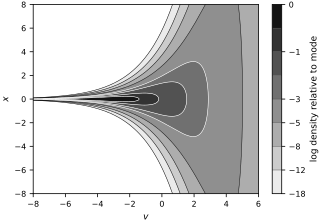

In [3]:
v = np.linspace(-8.0, 6.0, 300)
x = np.linspace(-8.0, 8.0, 300)
V, X = np.meshgrid(v, x, indexing="xy")

log_density = (
    -0.5 * (V / 3.0) ** 2
    - 0.5 * np.log(2.0 * np.pi * 9.0)
    - 0.5 * X**2 / np.exp(V)
    - 0.5 * V
    - 0.5 * np.log(2.0 * np.pi)
)
relative_log_density = log_density - log_density.max()

levels = np.array([-18.0, -12.0, -8.0, -5.0, -3.0, -2.0, -1.0, -0.5, 0.0])
band_colors = ["0.92", "0.80", "0.68", "0.56", "0.44", "0.32", "0.20", "0.08"]
fig, ax = new_figure(size="print_full")
filled = ax.contourf(
    V, X, relative_log_density, levels=levels, colors=band_colors
)
ax.contour(
    V,
    X,
    relative_log_density,
    levels=levels[:4],
    colors="black",
    linestyles="solid",
    linewidths=0.5,
)
ax.contour(
    V,
    X,
    relative_log_density,
    levels=levels[4:-1],
    colors="white",
    linestyles="solid",
    linewidths=0.5,
)
ax.set_xlabel(r"$v$")
ax.set_ylabel(r"$x$")
colorbar = fig.colorbar(
    filled,
    ax=ax,
    ticks=[-18.0, -12.0, -8.0, -5.0, -3.0, -1.0, 0.0],
    label="log density relative to mode",
    spacing="uniform",
    drawedges=True,
)
colorbar.dividers.set_color("0.25")
colorbar.dividers.set_linewidth(0.4)
colorbar.ax.tick_params(labelsize=8)
_ = finalize_axes(ax, keep_box=True)
plt.show()

## A hierarchical example: eight schools

The funnel matters because hierarchical posteriors often develop the same shape. We will use the classic eight-schools dataset {cite:p}`rubin1981schools`. Each school has an estimated treatment effect $y_j$ with known standard error $\sigma_j$.

The centered hierarchical model is

$$
\mu \sim \mathcal{N}(0, 5^2), \qquad \tau \sim \text{HalfNormal}(5),
$$

$$
\theta_j \mid \mu, \tau \sim \mathcal{N}(\mu, \tau^2),
$$

$$
y_j \mid \theta_j \sim \mathcal{N}(\theta_j, \sigma_j^2).
$$

When $\tau$ becomes small, all school-level effects $\theta_j$ are forced into a narrow region near $\mu$. This creates the same kind of neck we saw in Neal's funnel.


In [4]:
y = jnp.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
sigma = jnp.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])

def centered_model(y=None, sigma=None):
    mu = numpyro.sample("mu", dist.Normal(0.0, 5.0))
    tau = numpyro.sample("tau", dist.HalfNormal(5.0))
    theta = numpyro.sample("theta", dist.Normal(mu, tau).expand([len(y)]))
    numpyro.sample("obs", dist.Normal(theta, sigma), obs=y)

def noncentered_model(y=None, sigma=None):
    mu = numpyro.sample("mu", dist.Normal(0.0, 5.0))
    tau = numpyro.sample("tau", dist.HalfNormal(5.0))
    eta = numpyro.sample("eta", dist.Normal(jnp.zeros(len(y)), 1.0))
    theta = numpyro.deterministic("theta", mu + tau * eta)
    numpyro.sample("obs", dist.Normal(theta, sigma), obs=y)

def run_mcmc(model, key, y, sigma):
    kernel = NUTS(model, target_accept_prob=0.8)
    mcmc = MCMC(kernel, num_warmup=500, num_samples=1000, num_chains=2, progress_bar=False)
    mcmc.run(key, y=y, sigma=sigma)
    return mcmc

## Centered versus noncentered sampling

The noncentered parameterization introduces latent standard-normal variables

$$
\eta_j \sim \mathcal{N}(0, 1), \qquad \theta_j = \mu + \tau \eta_j.
$$

This does **not** change the substantive model. It only changes the coordinates in which the sampler explores the posterior. If the geometry becomes more regular in these new coordinates, HMC and NUTS can move much more effectively.


In [5]:
rng_key, centered_key, noncentered_key = jax.random.split(rng_key, 3)

centered_mcmc = run_mcmc(centered_model, centered_key, y, sigma)
noncentered_mcmc = run_mcmc(noncentered_model, noncentered_key, y, sigma)

centered_divergences = int(centered_mcmc.get_extra_fields(group_by_chain=True)["diverging"].sum())
noncentered_divergences = int(noncentered_mcmc.get_extra_fields(group_by_chain=True)["diverging"].sum())

print(f"Centered model divergences:    {centered_divergences}")
print(f"Noncentered model divergences: {noncentered_divergences}")

Centered model divergences:    500
Noncentered model divergences: 0


In [6]:
centered_idata = az.from_numpyro(centered_mcmc)
noncentered_idata = az.from_numpyro(noncentered_mcmc)

centered_summary = az.summary(centered_idata, var_names=["mu", "tau"], kind="diagnostics")
noncentered_summary = az.summary(noncentered_idata, var_names=["mu", "tau"], kind="diagnostics")

comparison = pd.concat(
    {
        "centered": centered_summary[["ess_bulk", "ess_tail", "r_hat"]],
        "noncentered": noncentered_summary[["ess_bulk", "ess_tail", "r_hat"]],
    },
    axis=1,
)
comparison

centered                       noncentered                       
     ess_bulk   ess_tail     r_hat     ess_bulk     ess_tail     r_hat
mu   4.760794  11.309304  1.345353  2263.023759  1327.369730  1.005227
tau  3.354140   3.230288  1.610632  1328.214614  1109.012119  1.000235

## Geometry in the sampler coordinates

The next figure shows two standard diagnostics.

- The trace of $\tau$ should mix well across chains.
- Divergences should not cluster in a geometrically difficult region.

For the centered model we plot $(\tau, \theta_1)$. For the noncentered model we plot $(\tau, \eta_1)$, because this is the parameterization in which the sampler actually moves.


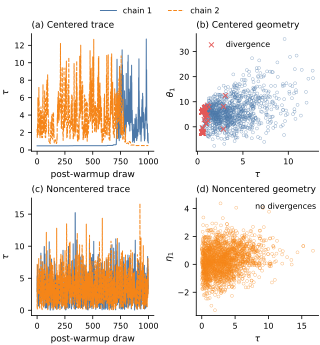

In [7]:
centered_samples = centered_mcmc.get_samples(group_by_chain=True)
noncentered_samples = noncentered_mcmc.get_samples(group_by_chain=True)
centered_extra = centered_mcmc.get_extra_fields(group_by_chain=True)
noncentered_extra = noncentered_mcmc.get_extra_fields(group_by_chain=True)

fig, axes = new_figure(size="print_four_panel", nrows=2, ncols=2)
chain_styles = [
    (BOOK_COLORS["blue"], "-"),
    (BOOK_COLORS["orange"], "--"),
]

for chain in range(centered_samples["tau"].shape[0]):
    color, linestyle = chain_styles[chain]
    axes[0, 0].plot(
        centered_samples["tau"][chain],
        color=color,
        linestyle=linestyle,
        linewidth=1.0,
        label=f"chain {chain + 1}",
    )
axes[0, 0].set_title("(a) Centered trace", loc="left")
axes[0, 0].set_xlabel("post-warmup draw")
axes[0, 0].set_ylabel(r"$\tau$")
chain_handles, chain_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(chain_handles, chain_labels, loc="outside upper center", ncol=2)

axes[0, 1].scatter(
    np.ravel(np.asarray(centered_samples["tau"])),
    np.ravel(np.asarray(centered_samples["theta"][..., 0])),
    s=9,
    facecolors="none",
    edgecolors=BOOK_COLORS["blue"],
    linewidths=0.45,
    alpha=0.6,
)
centered_div_mask = np.ravel(np.asarray(centered_extra["diverging"]))
axes[0, 1].scatter(
    np.ravel(np.asarray(centered_samples["tau"]))[centered_div_mask],
    np.ravel(np.asarray(centered_samples["theta"][..., 0]))[centered_div_mask],
    s=24,
    color=BOOK_COLORS["red"],
    marker="x",
    linewidths=0.9,
    label="divergence",
)
axes[0, 1].set_title("(b) Centered geometry", loc="left")
axes[0, 1].set_xlabel(r"$\tau$")
axes[0, 1].set_ylabel(r"$\theta_1$")
axes[0, 1].legend()

for chain in range(noncentered_samples["tau"].shape[0]):
    color, linestyle = chain_styles[chain]
    axes[1, 0].plot(
        noncentered_samples["tau"][chain],
        color=color,
        linestyle=linestyle,
        linewidth=1.0,
        label=f"chain {chain + 1}",
    )
axes[1, 0].set_title("(c) Noncentered trace", loc="left")
axes[1, 0].set_xlabel("post-warmup draw")
axes[1, 0].set_ylabel(r"$\tau$")

axes[1, 1].scatter(
    np.ravel(np.asarray(noncentered_samples["tau"])),
    np.ravel(np.asarray(noncentered_samples["eta"][..., 0])),
    s=9,
    facecolors="none",
    edgecolors=BOOK_COLORS["orange"],
    linewidths=0.45,
    alpha=0.6,
)
noncentered_div_mask = np.ravel(np.asarray(noncentered_extra["diverging"]))
if noncentered_div_mask.any():
    axes[1, 1].scatter(
        np.ravel(np.asarray(noncentered_samples["tau"]))[noncentered_div_mask],
        np.ravel(np.asarray(noncentered_samples["eta"][..., 0]))[noncentered_div_mask],
        s=24,
        color=BOOK_COLORS["red"],
        marker="x",
        linewidths=0.9,
        label="divergence",
    )
    axes[1, 1].legend()
else:
    axes[1, 1].text(
        0.98,
        0.96,
        "no divergences",
        transform=axes[1, 1].transAxes,
        ha="right",
        va="top",
        fontsize=8,
    )
axes[1, 1].set_title("(d) Noncentered geometry", loc="left")
axes[1, 1].set_xlabel(r"$\tau$")
axes[1, 1].set_ylabel(r"$\eta_1$")
_ = finalize_axes(axes)
plt.show()

## Same model, different coordinates

The noncentered parameterization is not a different scientific model. It is the same posterior written in a geometry that is easier for the sampler. To emphasize that point, we compare the marginal posterior of $\tau$ under both parameterizations. Because the centered run contains divergences and has a much lower effective sample size, any residual difference between the histograms indicates poor exploration by that run, not a difference in the underlying model.


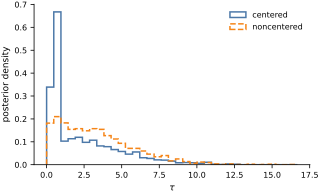

In [8]:
centered_tau = np.ravel(np.asarray(centered_samples["tau"]))
noncentered_tau = np.ravel(np.asarray(noncentered_samples["tau"]))
shared_bins = np.histogram_bin_edges(
    np.concatenate([centered_tau, noncentered_tau]), bins=35
)

fig, ax = new_figure(size="print_compact")
ax.hist(
    centered_tau,
    bins=shared_bins,
    density=True,
    histtype="step",
    color=BOOK_COLORS["blue"],
    linestyle="-",
    linewidth=1.5,
    label="centered",
)
ax.hist(
    noncentered_tau,
    bins=shared_bins,
    density=True,
    histtype="step",
    color=BOOK_COLORS["orange"],
    linestyle="--",
    linewidth=1.5,
    label="noncentered",
)
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("posterior density")
ax.legend()
_ = finalize_axes(ax)
plt.show()

## Consequences for sampling

There are four practical lessons here.

1. Bad posterior geometry is often a coordinate problem, not a modeling mistake.
2. Divergences are not cosmetic warnings. They are telling us that the sampler cannot reliably follow the posterior geometry.
3. Hierarchical models are especially vulnerable when a scale parameter, such as $\tau$, can become very small.
4. Noncentering is often the first repair to try when a hierarchical model develops funnel-like behavior.

Reliable uncertainty quantification requires both a defensible probabilistic model and a parameterization that the sampler can explore.


## Exercises

1. Increase the number of warmup and sampling steps. Does the centered model improve, or do divergences remain persistent?
2. Change the prior scale on $\tau$. How does that alter the severity of the funnel?
3. Lower the `target_accept_prob` in NUTS. How quickly do divergences appear in the centered model?
4. Repeat the experiment on another hierarchical model from this book. Can you identify whether it should be centered or noncentered?
5. Replace the eight-schools data with synthetic data where the group-level scale is clearly large. Does the centered parameterization become less problematic?
